# Signal Detection Theory

## Old/New Recognition Task - Equal-Variance Gaussian SDT Model

This example demonstrates parameter recovery for a classic old/new recognition-memory task. On each trial the participant is shown either a previously studied item (`is_old=1`) or a novel item (`is_old=0`), and responds "old" (`resp_old=1`) or "new" (`resp_old=0`).

Under the equal-variance Gaussian signal detection theory (SDT) model, internal evidence for old items is drawn from $N(+d'/2, 1)$ and evidence for new items is drawn from $N(-d'/2, 1)$. The participant responds "old" whenever the sampled evidence exceeds a response criterion $c$.

$$
\textbf{Hit rate:}\quad
P(\text{resp old} \mid \text{old item}) = \Phi\!\left(\frac{d'}{2} - c\right) \tag{1}
$$

$$
\textbf{False-alarm rate:}\quad
P(\text{resp old} \mid \text{new item}) = \Phi\!\left(-\frac{d'}{2} - c\right) \tag{2}
$$

where $\Phi$ is the standard normal CDF. Free parameters: sensitivity ($d'$, `dprime`) and response bias (`criterion`). Each trial's response is Bernoulli given the corresponding probability above, so the per-subject likelihood is a product of per-trial Bernoulli terms.

In [1]:
import numpy as np
from pyem import EMModel
from pyem.models.sdt import sdt_model
from params import build_params

# ModelSpec bundles this model's identity, description, and sim/fit entry points
print(f"Model ID   : {sdt_model.id}")
print(f"Description: {sdt_model.desc}")
print(f"Spec       : {sdt_model.spec}")

Model ID   : sdt
Description: Equal-variance Gaussian signal detection theory (SDT) model of an
old/new recognition memory task. Internal evidence for studied ("old") items
is drawn from N(+d'/2, 1) and for novel ("new") items from N(-d'/2, 1); the
subject responds "old" whenever evidence exceeds a response criterion c.
Free parameters: sensitivity (dprime, d' >= 0), response bias (criterion, c).

Optional extension (not implemented here): a type-2/confidence variant that
replaces the single yes/no criterion with multiple ordered criteria to model
graded confidence ratings alongside old/new responses.
Spec       : {'sdt': {'gaussian_equal_variance': ['dprime', 'criterion']}}


In [2]:
# simulate computer agents completing the old/new recognition task
nsubjects, ntrials = 80, 200

# generate "true" parameters using the shared parameter registry (examples/params.py)
param_names, param_xform, true_params = build_params(
    ["dprime", "criterion"], nsubjects, rng=np.random.default_rng(0)
)

recover(): this model's data and outfit now reflect the recovery fit; the recovered estimates are also in the returned dict['recovery_model'].


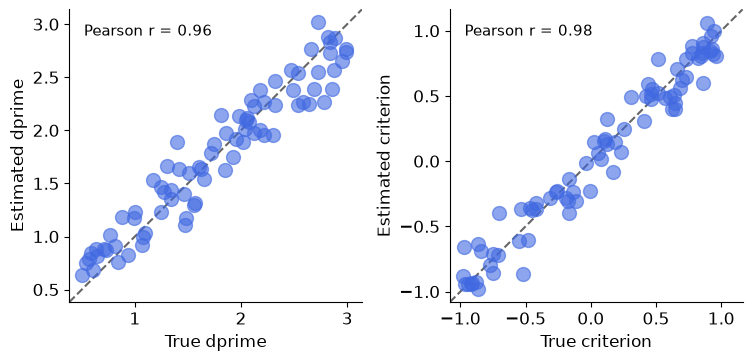

In [3]:
# use EMModel.recover to run simulation, fitting and recovery metrics
model = EMModel(all_data=None, fit_func=sdt_model.fit,
                param_names=param_names,
                param_xform=param_xform,
                simulate_func=sdt_model.sim)

recovery = model.recover(true_params,
                         pr_inputs=["is_old", "resp_old"],
                         ntrials=ntrials,
                         fit_kwargs={"seed": 0, "mstep_maxit": 30, "njobs": 1}
                         )

# scatter plot of recovered parameters
fig = model.plot_recovery(recovery, show=False)

The recovery dictionary also contains numerical summaries such as `recovery['correlation']`, which provides a correlation coefficient for each parameter (here: `dprime`, `criterion`).

**References**

Green, D. M. (1966). Signal detection theory and psychophysics.

Lockhart, R. S., & Murdock, B. B. (1970). Memory and the theory of signal detection. *Psychological Bulletin*, 74(2), 100–109. https://doi.org/10.1037/h0029536
